In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")

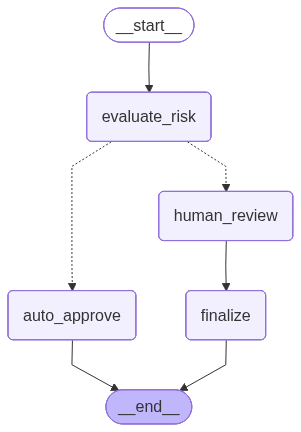

In [22]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langgraph.types import interrupt
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
import uuid


# ====================================================
# 1️⃣ Define Workflow State
# ====================================================
class LoanState(TypedDict, total=False):
    applicant_name: str
    income: int
    loan_amount: int
    risk_level: str
    human_approved: bool
    final_decision: str


# ====================================================
# 2️⃣ Risk Evaluation Logic
# ====================================================
def evaluate_risk(state: LoanState):
    income = state["income"]
    loan = state["loan_amount"]

    ratio = loan / income

    if ratio > 5:
        risk = "high"
    elif ratio > 3:
        risk = "medium"
    else:
        risk = "low"

    return {"risk_level": risk}


# ====================================================
# 3️⃣ Routing Logic
# ====================================================
def route_risk(state: LoanState):
    if state["risk_level"] == "low":
        return "auto_approve"
    return "human_review"


# ====================================================
# 4️⃣ Auto Approval (END immediately)
# ====================================================
def auto_approve(state: LoanState):
    return {
        "human_approved": False,
        "final_decision": f"Loan Auto Approved for {state['applicant_name']} "
                          f"for amount {state['loan_amount']}"
    }


# ====================================================
# 5️⃣ Human Review (Pause Here)
# ====================================================
def human_review(state: LoanState):

    # ✅ If manager already approved, skip interrupt
    if state.get("human_approved") is not None:
        return {}

    # ⛔ Otherwise pause workflow
    return interrupt(
        {
            "message": "Manager approval required",
            "applicant": state["applicant_name"],
            "income": state["income"],
            "loan_amount": state["loan_amount"],
            "risk_level": state["risk_level"],
        }
    )

# ====================================================
# 6️⃣ Final Decision After Manager Approval
# ====================================================
def finalize(state: LoanState):
    if state.get("human_approved"):
        return {
            "final_decision": f"Loan Approved by Manager for {state['applicant_name']}"
        }
    return {
        "final_decision": f"Loan Rejected by Manager for {state['applicant_name']}"
    }


# ====================================================
# 7️⃣ Setup SQLite Persistence
# ====================================================
conn = sqlite3.connect("loan.db", check_same_thread=False)
checkpointer = SqliteSaver(conn)

builder = StateGraph(LoanState)

builder.add_node("evaluate_risk", evaluate_risk)
builder.add_node("auto_approve", auto_approve)
builder.add_node("human_review", human_review)
builder.add_node("finalize", finalize)

builder.set_entry_point("evaluate_risk")

builder.add_conditional_edges(
    "evaluate_risk",
    route_risk,
    {
        "auto_approve": "auto_approve",
        "human_review": "human_review",
    },
)

builder.add_edge("auto_approve", END)
builder.add_edge("human_review", "finalize")
builder.add_edge("finalize", END)

graph = builder.compile(checkpointer=checkpointer)
graph 


In [19]:

# ====================================================
# 🧪 TEST FUNCTION
# ====================================================
def run_test(applicant, income, loan):
    print("\n==============================")
    print(f"Testing: {applicant}, Income={income}, Loan={loan}")
    print("==============================")

    config = {
        "configurable": {
            "thread_id": str(uuid.uuid4())  # fresh thread
        }
    }

    result = graph.invoke(
        {
            "applicant_name": applicant,
            "income": income,
            "loan_amount": loan
        },
        config=config,
    )

    print("First Run Output:")
    print(result)

    state = graph.get_state(config)

    if state.next:
        print("\n⏸ Workflow paused. Simulating Manager Approval...\n")

        resume = graph.invoke(
            {"human_approved": True},
            config=config,
        )

        print("After Manager Decision:")
        print(resume)
    else:
        print("\n✅ Workflow completed automatically.")


# ====================================================
# 🧪 TEST CASES
# ====================================================

# 🟢 LOW RISK → Auto Approve
run_test("Ravi Kumar", 30000, 20000)

# 🟡 MEDIUM RISK → Human Review
run_test("Amit Sharma", 30000, 100000)

# 🔴 HIGH RISK → Human Review
run_test("Priya Singh", 30000, 200000)


Testing: Ravi Kumar, Income=30000, Loan=20000
First Run Output:
{'applicant_name': 'Ravi Kumar', 'income': 30000, 'loan_amount': 20000, 'risk_level': 'low', 'human_approved': False, 'final_decision': 'Loan Auto Approved for Ravi Kumar for amount 20000'}

✅ Workflow completed automatically.

Testing: Amit Sharma, Income=30000, Loan=100000
First Run Output:
{'applicant_name': 'Amit Sharma', 'income': 30000, 'loan_amount': 100000, 'risk_level': 'medium', '__interrupt__': [Interrupt(value={'message': 'Manager approval required', 'applicant': 'Amit Sharma', 'income': 30000, 'loan_amount': 100000, 'risk_level': 'medium'}, id='6a00cf38984afaf83f6deaf9cea233f3')]}

⏸ Workflow paused. Simulating Manager Approval...

After Manager Decision:
{'applicant_name': 'Amit Sharma', 'income': 30000, 'loan_amount': 100000, 'risk_level': 'medium', 'human_approved': True, '__interrupt__': [Interrupt(value={'message': 'Manager approval required', 'applicant': 'Amit Sharma', 'income': 30000, 'loan_amount': 1

In [25]:
run_test("Amit das", 30000, 50000)


Testing: Amit das, Income=30000, Loan=50000
First Run Output:
{'applicant_name': 'Amit das', 'income': 30000, 'loan_amount': 50000, 'risk_level': 'low', 'human_approved': False, 'final_decision': 'Loan Auto Approved for Amit das for amount 50000'}

✅ Workflow completed automatically.
